In [37]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
RESULT_FILEPATH = '/Users/egyptdj/github/bruit-classification/results/results-231204/'
CAROTID_THRESHOLD = 0.5
BRUIT_THRESHOLD = 0.5
PRED_THRESHOLD = 3

In [39]:
sns.set_theme(context='talk', style='white', font='helvetica', font_scale=1.0)

In [40]:
results_files = os.listdir(RESULT_FILEPATH)
results_df = [pd.read_csv(os.path.join(RESULT_FILEPATH, f)) for f in results_files]

In [41]:
def get_pred(df):
    results_array = [np.array(ast.literal_eval(row)) for row in df['predictions']]
    carotid_array = [arr[:,0] for arr in results_array]
    bruit_array = [arr[:,1] for arr in results_array]
    labels = df['normal'].replace({0: 'Stenosis', 1: 'Control'}).to_list()
    
    carotid_pred = [(arr>CAROTID_THRESHOLD).mean() for arr in carotid_array]
    bruit_pred = [((barr>BRUIT_THRESHOLD)*(carr>CAROTID_THRESHOLD)).sum() for barr, carr in zip(bruit_array, carotid_array)]
    correct = [bool(label)!=(bpred>PRED_THRESHOLD) for label, bpred in zip(labels, bruit_pred)]
    
    return carotid_pred, bruit_pred, labels, correct
    

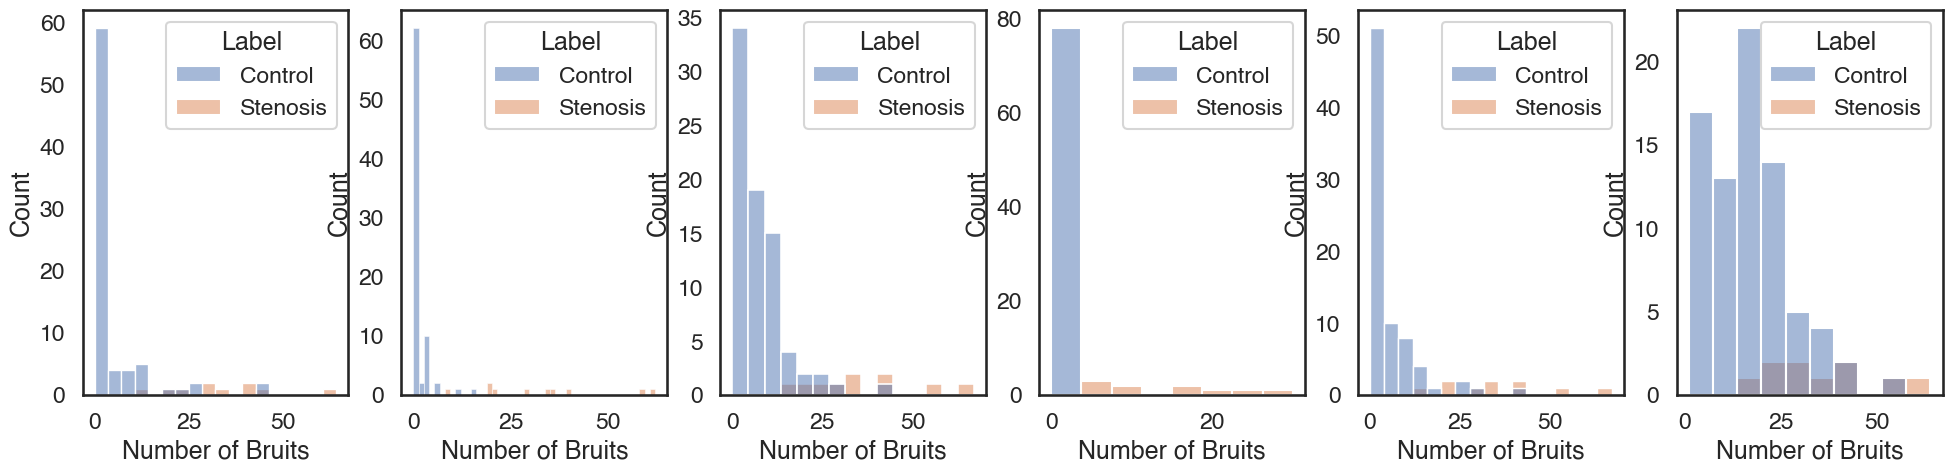

In [42]:
fig, ax = plt.subplots(figsize=(24, 5), ncols=len(results_df))
for i, (df, filename) in enumerate(zip(results_df, results_files)):
    cp, bp, label, correct = get_pred(df)
    histdf = pd.DataFrame.from_dict({'Number of Bruits': bp, 'Label': label})
    sns.histplot(data=histdf, x='Number of Bruits', hue='Label', ax=ax[i])

4번째 결과 가장 좋으므로 results_files[3] 을 기준으로 분석

In [43]:
df = results_df[3]
print(results_files[3])

231204-model_noiseasnormal_nomult_step2mlp64_twostep_length15600.csv


In [44]:
cp, bp, label, correct = get_pred(df)

In [45]:
bp_stenosis = []
bp_control = []
for l, p in zip(label, bp):
    if l=='Stenosis':
        bp_stenosis.append(p)
    else:
        bp_control.append(p)
print(min(bp_stenosis), max(bp_stenosis))
print(min(bp_control), max(bp_control))

5 30
0 2


Rectangle(xy=(0, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(3.75, 0), width=3.75, height=3, angle=0)
Rectangle(xy=(7.5, 0), width=3.75, height=2, angle=0)
Rectangle(xy=(11.25, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(15, 0), width=3.75, height=2, angle=0)
Rectangle(xy=(18.75, 0), width=3.75, height=1, angle=0)
Rectangle(xy=(22.5, 0), width=3.75, height=1, angle=0)
Rectangle(xy=(26.25, 0), width=3.75, height=1, angle=0)
Rectangle(xy=(0, 0), width=3.75, height=78, angle=0)
Rectangle(xy=(3.75, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(7.5, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(11.25, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(15, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(18.75, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(22.5, 0), width=3.75, height=0, angle=0)
Rectangle(xy=(26.25, 0), width=3.75, height=0, angle=0)


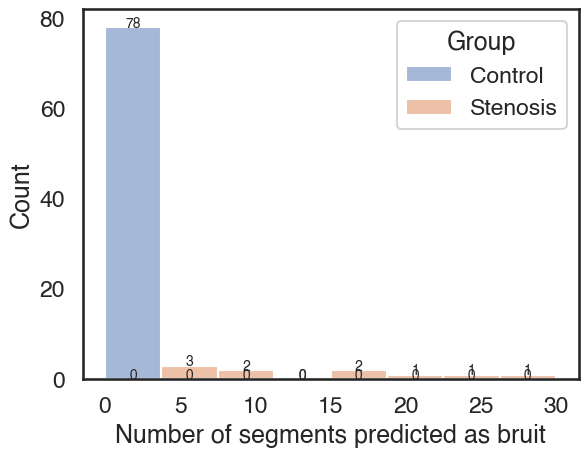

In [46]:
histdf = pd.DataFrame.from_dict({'Bruits': bp, 'Group': label})
ax = sns.histplot(data=histdf, x='Bruits', hue='Group')
ax.set(xlabel='Number of segments predicted as bruit')
for i, p in enumerate(ax.patches):
    print(p)
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10)

0.9142965579819258 1.0 0.7021276595744681


[Text(0.5, 0, 'Carotid sound to background noise ratio')]

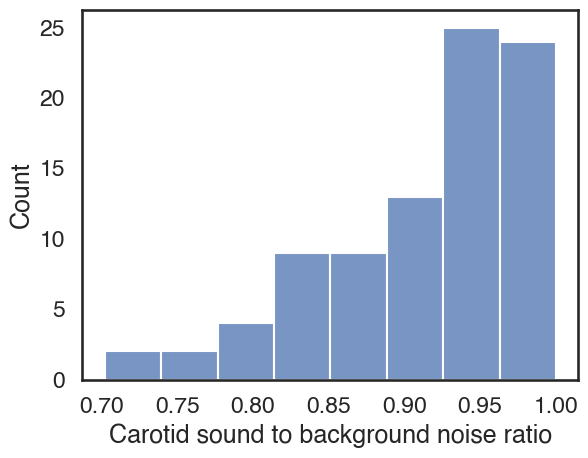

In [47]:
print(np.mean(cp), max(cp), min(cp))
sns.histplot(x=cp).set(xlabel='Carotid sound to background noise ratio')

In [48]:
TEST_METRIC_FILE = 'models/model_noiseasnormal_nomult_step2mlp64_twostep_length15600/test_metrics.csv'
metric_df = pd.read_csv(TEST_METRIC_FILE)
metric_df.columns = ['Model', 'Loss', 'Accuracy', 'Precision', 'Recall', 'ROC AUC']
metric_df = metric_df.replace({'step1': 'Carotid sound recognizer', 'step2': 'Bruit classifier'})
metric_df[['Accuracy', 'Precision', 'Recall']] = metric_df[['Accuracy', 'Precision', 'Recall']].apply(lambda x: x*100)
metric_df

,Model,Loss,Accuracy,Precision,Recall,ROC AUC
0,Carotid sound recognizer,0.2469,91.52,77.04,82.57,0.9887
1,Bruit classifier,0.3636,81.69,87.76,49.40,0.6891
